# Exercise 2 - 184.702 Machine Learning (VU 3,0) 2025W
## Description
**TASK**

Implement a regression tree algorithm and a random forest algorithm (based on the implemented regression tree algorithm) for predicting numeric values– You can find various implementations for these algorithms. However, we can also apply our own ideas for splitting of instances
+ We should implement these algorithms from scratch (not using any part of existing code)
+ We can use existing code/functions for general parts like: Code for reading the input and testing the algorithm (cross- validation, performance metrics for regression...) 

**COMPARISON**

Compare the implemented techniques with the existing implementations of regression trees/random forest and one other existing regression techniques (we may use the default parameters for the existing techniques) 

+ Experiment with at least three configurations (number of trees, ...) for random 
forest
+ Using at least two performance metrics for comparison
+ Applying cross-validation

***Conclusions***
+ How efficient are our algorithms?
+ Performance of our algorithms?
+ Other findings


# RegressionTree Implementation


## Code section

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# for testing and comparison
import time
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# for parallelization!
from joblib import Parallel, delayed


from typing import Literal, Dict, Any, Self
from numpy.typing import ArrayLike

import logging

logging.basicConfig(level=logging.WARNING,
                    format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger()
logger.setLevel(logging.WARNING)

The principle of building a Regression Tree follows the same approach as the creation of a Classification Tree.

We search for the feature which splits the target feature values most purely, divide the dataset along the values of this descriptive feature and repeat this process for each of the sub datasets until we accomplish a stopping criteria. If we accomplish a stopping criteria, we grow a leaf node.

Most notable difference is when to stop:
If we now consider the property of our new continuously scaled target feature we mention that the third stopping criteria can no longer be used since the target feature values can now take on an infinite number of different values. Consequently, it is most likely that we will not find pure target feature values until there is only one instance left in the dataset.

Long story short, there is in general nothing like pure target feature values.

To address this issue, we will introduce an early stopping criteria that returns the average value of the target feature values left in the dataset if the number of instances in the dataset is e.g. <= 5.

In [34]:
def dict_depth(dic, level = 1):
    
    if not isinstance(dic, dict) or not dic:
        return level
    
    return max(dict_depth(dic[key], level + 1)
                               for key in dic)
    
class RegressionTreeNico():
    '''
    Custom implementation of a regression decision tree for 
    184.702 Machine Learning (VU 3,0) 2025W

    This class builds a regression tree from scratch and supports both
    categorical and continuous features. It uses variance/MSE reduction
    as the splitting criterion. It also supports recursive tree growth with
    configurable stopping criteria (minimum instances per leaf, maximum depth).

    '''    

    def __init__(self, random_state=None) -> None:
        self.random_state=random_state

    def _calc_MSE(self, Y_true: ArrayLike, Y_pred: ArrayLike) -> np.float64:
        '''
        Calculates mean squared error

        Returns:
            MSE of given features
        
        '''
        return np.square(np.subtract(Y_true, Y_pred)).mean()
    
    def _calc_variance_cat_features(self, data: ArrayLike, target_name: str, which_feature_name: str) -> np.float64:
        '''
        Used to calculate the variance of categorical features to decide which feature to use for the next leaf via minimum variance!

        Parameters
        ----------
        data : ArrayLike
            The data set in which we want to calculate the variance for a given feature
        target_name: str
            Name of the target feature
        which_feature_name: str
            Name of the feature for which we want to calculate the variance.

        Returns
        -------
        np.float64
            The (weighted) variance of the feature in the given data
        '''
        # TODO: Do this all with numpy and avoid the pandas overhead!
        # prep building blocks for vectorized variance calculation
        grouped_data = data.groupby(which_feature_name)[target_name]
        sizes = grouped_data.size()
        
        # In case we have only one appearance of a value (size N = 1), 
        # then we have to make sure it makes 0 instead of inf because of the division / (N - 1)
        feature_variances = grouped_data.var(ddof=1).fillna(0) 

        weighted_feature_variances = (sizes / len(data)) * feature_variances

        # return the total weighted variance for the feature
        return weighted_feature_variances.sum()
    
        # old non-vectorized part
        feature_values = np.unique(data[which_feature_name])
        feature_variance = 0

        for value in feature_values:
            subset = data[data[which_feature_name] == value].reset_index()

            # In case we have only one appearance of a value, then we have to make sure it makes 0 instead of inf because of the division / (N - 1)
            if len(subset) <= 1:
                subset_var = 0.0
            else:
                # standard in np.var is divided by N instead of N - 1!
                subset_var = (len(subset)/len(data)) * np.var(subset[target_name], ddof=1)

            feature_variance += subset_var
        
        return feature_variance
    
    def _calc_variance_cont_features(self, data: ArrayLike, target_name: str, which_feature_name: str) -> np.float64:
        '''
        Used to calculate the variance of continous features to decide which feature to use for the next leaf via minimum variance!
        
        Parameters
        ----------
        data : ArrayLike
            The data set in which we want to calculate the variance for a given feature
        target_name: str
            Name of the target feature
        which_feature_name: str
            Name of the feature for which we want to calculate the variance.

        Returns
        -------
        np.float64
            The (weighted) variance of the feature in the given data
        '''   

        # initialize weighted mse
        best_weighted_mse = np.inf
        best_threshold = np.inf

        # removed the following block as it is pandas slicing which is less performant than the numpy series afterwards
        # sort the data by the feature
        #data = data.sort_values(by=which_feature_name)
        #X = data[which_feature_name].values
        #y = data[target_name].values
        feature_idx = data.columns.get_loc(which_feature_name)
        target_idx = data.columns.get_loc(target_name)
        
        data = data.to_numpy()
        X = data[:, feature_idx]
        y = data[:, target_idx]

        # sort the data by the feature
        sort_idx = np.argsort(X)
        X = X[sort_idx]
        y = y[sort_idx]

        # now do all the things we did in the loop in one step!
        # summing up enables us to calculate for each i in a loop to have the sums/means already:
        
        # left side 
        cum_sum = np.cumsum(y)
        cum_squared_sum = np.cumsum(y**2)
        counts = np.arange(1, len(y) + 1) 
        
        # e.g. for i = 4
        # + cum_sum = sum up until 4th row
        # + counts = well.. four

        # mse can also be written (after rearranging) as:
        # 1/N * sum_over_i(y_i**2) - mean**2
        left_mean = cum_sum[:-1] / counts[:-1] # -1: everything but the last as this would be the total sum
        left_mse = (cum_squared_sum[:-1] / counts [:-1]) - left_mean**2 
        
        # total values as prep for right side 
        total_sum = cum_sum[-1]
        total_squared_sum = cum_squared_sum[-1]
        total_count = len(y)

        # right side
        right_sum = total_sum - cum_sum[:-1]
        right_sq_sum = total_squared_sum - cum_squared_sum[:-1]
        right_count = total_count - counts[:-1]

        right_mean = right_sum / right_count
        right_mse = (right_sq_sum / right_count) - right_mean**2

        # weighted MSE for all the different splits
        weighted_mse = (counts[:-1] * left_mse + right_count * right_mse) / total_count

        # "consecutive" rows for the threshold (basically shifting the X up and down visually to overlap consecutively)
        threshold = (X[1:] + X[:-1]) / 2

        best_split = np.argmin(weighted_mse)

        # return the best wmse as well as the threshold
        return weighted_mse[best_split], threshold[best_split]

        # find here the "old" for loop for the exact same functionality as above!

        # compute the mse at current node
        current_yhat = np.mean(data[target_name].mean())
        current_mse = self._calc_MSE(data[target_name], current_yhat)
        current_mse = np.round(current_mse, 3)

        # iterate over all rows of the SORTED data
        for i in range(1, len(data)):
            logger.info(data)
            logger.info(which_feature_name)
            logger.info(f"{data.iloc[i][which_feature_name]}, {data.iloc[i-1][which_feature_name]}")
            # compute average of two consecutive rows to have some threshold start 
            split_val = (data.iloc[i][which_feature_name] + data.iloc[i-1][which_feature_name]) / 2

            # split the data into the two sides
            left_branch = data[data[which_feature_name]<=split_val]
            right_branch = data[data[which_feature_name]>split_val]

            # compute the MSE of both sides
            left_yhat = np.mean(left_branch[target_name]) 
            left_mse = self._calc_MSE(left_branch[target_name], left_yhat) 

            right_yhat = np.mean(right_branch[target_name]) 
            right_mse = self._calc_MSE(right_branch[target_name], right_yhat) 

            # compute weighted MSE
            weighted_mse = ((len(left_branch) * left_mse) + (len(right_branch) * right_mse))/len(data)

            # update bestbest_weighted_mse
            if weighted_mse <= best_weighted_mse:
                best_weighted_mse = weighted_mse
                best_threshold = split_val

        return best_weighted_mse, best_threshold

    def _calc_entropy(self, target_column: str) -> np.float64:
        '''
        Calculate the entropy of a target column
       
        Parameters
        ----------
        target_column : ArrayLike
            The target column of which we want to calculate the entropy

        Returns
        -------
        np.float64
            The entropy of the given target column    
        '''

        elements, counts = np.unique(target_column, return_counts = True)

        entropy = np.sum([(-counts[i]/np.sum(counts)) * np.log2(counts[i] / np.sum(counts)) for i in range(len(elements))])
        
        return entropy
    
    def _calc_information_gain(self, data: ArrayLike, target_name:str, which_feature_name: str) -> np.float64:
        '''
        Calculate the information gain based on an attribute (with its weighted entropy!) and the target variable entropy
        
        Parameters
        ----------
        data : ArrayLike
            The data set in which we want to calculate the information gain for a given feature
        target_name: str
            Name of the target feature
        which_feature_name: str
            Name of the feature for which we want to calculate the information gain.

        Returns
        -------
        np.float64
            The infomation gain of the given column    
        '''
        target_entropy = self._calc_entropy(data[target_name])

        vals, counts = np.unique(data[which_feature_name], return_counts=True)

        # Calculate the WEIGHTED entropy
        weighted_entropy = np.sum([(counts[i] / np.sum(counts)) * self._calc_entropy(data[data[which_feature_name]==vals[i]].dropna()[target_name]) for i in range(len(vals))])
    
        # Calculate the information gain
        information_gain = target_entropy - weighted_entropy
        
        return information_gain
    
    def _sample_random_features(self, features: list, max_features: int) -> list:
        '''
        Used for sampling a subset of the given features.
        Funfact I originally did this in the RandomForest module on tree level. That way we got high correlation
        of the trees and hence even a decrease in performance!! So we need to do this actually at each node
        in each tree!!

        Paramters
        -------
        features: list
            list of features
        max_features: int
            maximum number of features wished to be kept

        Returns
        -------
            a subset (list) of randomly choosen features based on the max_features nr
        
        
        '''
        if not isinstance(features, list):
            raise ValueError(f"The features need to be passed as a list. It is of type {type(features)}")
        
        # reasoning for "new" way of setting seeds. Not globally but "locally" now
        # https://builtin.com/data-science/numpy-random-seed

        rng = np.random.default_rng(self.random_state)

        # replace=False is quite important as default is True, this would "duplicate" features with bad luck
        random_choice = rng.choice(features, size=int(max_features), replace=False)

        return random_choice
    
    def _find_best_split(self, 
                         data: pd.DataFrame, 
                         target_name: str, 
                         max_features: int = None,
                         categorical_features:list = []) -> Dict:
        best_feature = None
        best_threshold = None
        best_variance = np.inf
        is_continuous = False

        if max_features is not None:
            sample_features = np.append(self._sample_random_features(data.drop(target_name, axis=1).columns.to_list(),
                                                                     max_features=max_features), target_name)
            data = data[sample_features]

        for feature_name in data.columns:
            logger.info(f"passed categorical_features: {categorical_features}")
            if feature_name == target_name:
                continue

            elif feature_name in categorical_features:
                logger.info(f"feature {feature_name} entered categorical processing step")
                variance = self._calc_variance_cat_features(data, target_name, feature_name)
                
                # if improvement: overwrite values
                if variance <= best_variance:
                    best_feature = feature_name
                    best_threshold = None
                    best_variance = variance
                    is_continuous = False
            
            else:
                logger.info(f"feature {feature_name} entered continous processing step")

                variance, threshold = self._calc_variance_cont_features(data, target_name, feature_name)
                                
                # if improvement: overwrite values
                if variance <= best_variance:
                    best_feature = feature_name
                    best_threshold = threshold
                    best_variance = variance
                    is_continuous = True
        
        return best_feature, best_threshold, best_variance, is_continuous

    def _Classfier(
            self, 
            data: pd.DataFrame, 
            target_name: str, 
            min_instances: int = 2, 
            categorical_features: list = [],
            max_features: int = None, 
            max_depth: int = None, 
            features: list = None,
            depth: int = 0) -> dict[str, Any]:
        '''
        Recursive tree building algorithm.

        Parameters
        ----------
        data : pd.DataFrame
            Subset of the dataset at the current node.
        target_name : str
            Name of the target column
        min_instances : int, optional
            Minimum number of samples required to allow further splitting, else mean is taken.
        categorical_features : list, optional (but actually necessary in case of such)
            List of feature names that represent categorical features
        max_depth : int, optional
            Maximum depth of the tree. If None, the tree grows until min_instances is reached
        features : list, optional
            List of (remaining) features available for splitting
        depth : int, optional
            Depth of the recursion. Used internally

        Returns
        -------
        dict[str, Any] or float
            A nested dictionary representing the tree structure. 
            "Any" will be another such dictionary or a float (= mean target value) if the leaf node is reached

        
        '''
        # Stopping criterion for the recurrsion if we require some minimum value for the size/length of a sub dataset
        if len(data) < min_instances:
            prediction = float(np.mean(data[target_name]))
            return {
                "samples": len(data),
                "prediction": prediction,
                "error": self._calc_MSE(data[target_name], prediction)
            }
            return np.mean(data[target_name])
    
        # If the dataset has reached the wished for tdepth, return the mean target feature value of the remaining dataset as before
        elif max_depth != None and depth >= max_depth:
            prediction = float(np.mean(data[target_name]))
            return {
                "samples": len(data),
                "prediction": prediction,
                "error": self._calc_MSE(data[target_name], prediction)
            }
            return np.mean(data[target_name])

        # Now this is the actual "tree growing" part
        else:
            # get the best split
            best_feature, best_threshold, best_variance, is_continuous = self._find_best_split(data, 
                                                                                               target_name, 
                                                                                               max_features,
                                                                                               categorical_features
                                                                                               )

            features = list(data.columns)
            features.remove(target_name)

            # Small fallback in case of no best value found
            if best_feature == None:
                logger.info(f"No best feature to split on found. \nDepth: {depth} \nFeatures left: {features} ")
                return np.mean(data[target_name])

            if is_continuous:
                # build the branching for continous variables
                left_branch = data[data[best_feature] <= best_threshold]
                right_branch = data[data[best_feature] > best_threshold]
                
                ''' Structure for continous feature split:
                {
                    "feature": "X1",
                    "threshold": 400,
                    "left": { subtree(s) for X <= 400 or value in case we reached conditions (ie leaf node) above},
                    "right": { subtree(s) for X > 400 or value in case we reached conditions (ie leaf node) above},
                    "samples": number of samples at this node,
                    "prediction": mean of the target at this point,
                    "error": mse at this node if it was treated as a leaf
                }   
                '''
                
                # if the new split doesn't reduce the size (i.e. one of the branches has to be empty) we have to stop the recurssion
                if len(left_branch) == 0 or len(right_branch) == 0:
                    prediction = float(np.mean(data[target_name]))
                    return {
                        "samples": len(data),
                        "prediction": prediction,
                        "error": self._calc_MSE(data[target_name], prediction)
                    }
                
                if depth > 100:
                    logger.warning(f"Depth {depth}, feature {best_feature}, threshold {best_threshold}, "
                                f"left={len(left_branch)}, right={len(right_branch)}")
                return {
                    "feature": best_feature,
                    "threshold": best_threshold,
                    "left": self._Classfier(data=left_branch, 
                                            target_name=target_name, 
                                            categorical_features=categorical_features,
                                            min_instances=min_instances, 
                                            max_depth=max_depth, 
                                            depth= depth+1),
                    "right": self._Classfier(data=right_branch, 
                                             target_name=target_name, 
                                             categorical_features=categorical_features,
                                             min_instances=min_instances, 
                                             max_depth=max_depth, 
                                             depth= depth+1),
                    "samples": len(data),
                    "prediction": float(np.mean(data[target_name])),
                    "error": self._calc_MSE(data[target_name], np.mean(data[target_name]))
                }
            
            else:
                branches = {}
                for val in np.unique(data[best_feature]):
                    subset = data[data[best_feature] == val]

                    # If subset is the sane as parent, stop recursion as this gets stuck if the one var is always the best split
                    if len(subset) == len(data):
                        prediction = float(np.mean(data[target_name]))
                        return_dict = {
                            "samples": len(data),
                            "prediction": prediction,
                            "error": self._calc_MSE(data[target_name], prediction)
                        }
                        branches[val] = return_dict
                        continue

                    # keep this safeguard info here if we hit some weird recurssion depth issue again
                    if depth > 100:
                        logger.warning(f"Depth {depth}, value {val}, best_feature {best_feature}, lendata {len(data)}")
                    
                    branches[val] = self._Classfier(data=subset, 
                                                    target_name=target_name, 
                                                    categorical_features=categorical_features,
                                                    min_instances=min_instances, 
                                                    max_depth=max_depth, 
                                                    depth= depth+1)
                
                ''' Structure for non-continous feature split:
                {
                    "feature": "categoryXY",
                    "branches": { 
                        "X": subtree(s) for value "X" of feature categoryXY,
                        "Y": subtree(s) for value "Y" of feature categoryXY
                    },
                    "samples": number of samples at this node,
                    "prediction": mean of the target at this point,
                    "error": mse at this node if it was treated as a leaf
                }   
                '''
                
                return {
                    "feature": best_feature,
                    "branches": branches,
                    "samples": len(data),
                    "prediction": float(np.mean(data[target_name])),
                    "error": self._calc_MSE(data[target_name], np.mean(data[target_name]))
                }
    
    def fit(self, 
            data: pd.DataFrame, 
            target_name: str, 
            min_instances: int = 2,
            max_depth: int = None,
            max_features: int = None,
            features_to_choose: ArrayLike | pd.DataFrame = None,
            categorical_features: list = [],
            alpha: float = 0.0) -> Self:
            
        '''
        Creates ("fits") the regression tree to the given dataset.

        Parameters
        ----------
        data : pd.DataFrame
            Training dataset containing features AND the target
        target_name : str
            Name of the target column
        min_instances : int, optional
            Minimum number of samples required to allow further splitting, else mean is taken.
        max_depth : int, optional
            Maximum depth of the tree. If None, the tree grows until min_instances is reached
        features: list, optional
            Allows the user to choose only a subsample of the data for the fit
        categorical_features : list, optional (but actually necessary in case of such)
            List of feature names that represent categorical features
        alpha: float, optional
            If passed as != 0, this will enable cost-complexity pruning. 
            For more info look into the respective method "_prune_cost_complexity()"

        Returns
        -------
        Self
            Stores the learned tree in `self.tree_` of the initialized instance of this class.
        '''
        # to potentially reuse for normalization
        self.dataset_size = len(data)
        self.target_name = target_name
        self.categorical_features = categorical_features
        self.max_depth = max_depth
        self.min_instances = min_instances
        self.max_features = max_features

        # make sure we do not loose the target (and differentiate here as we also pass np.ndarray due to the random sampling)
        if features_to_choose is not None and target_name not in features_to_choose:
            if isinstance(features_to_choose, pd.DataFrame):
                features_to_choose.append(target_name)
            elif isinstance(features_to_choose, ArrayLike):
                #logger.error(f"{features_to_choose}, {type(features_to_choose)}, {target_name}")
                features_to_choose = np.append(features_to_choose, target_name)

        # Subsample if wanted
        if features_to_choose is not None:
            #logger.error(f"{features_to_choose}, {type(features_to_choose)}")
            data = data[features_to_choose]

        self.tree_ = self._Classfier(
            data, target_name, categorical_features=categorical_features, 
            min_instances=min_instances, max_depth=max_depth, max_features=max_features
        )
        
        # start pruning if alpha > 0.0 is passed
        if alpha > 0.0:
            self.tree_ = self._prune_cost_complexity(self.tree_, alpha)
        return self
        
    def _predict_row(self, X_pred: ArrayLike, tree:dict, features:list, categorical_features: list = []):
        logger.info(f"Entering _predict_row with (sub)tree: {tree}")
        logger.info(f"X_pred row: {X_pred}")
        logger.info(f"categorical_features passed to _predict_row: {categorical_features}")
        
        if tree["feature"] in features:
            feature = tree["feature"]
            logger.info(f"Checking for feature: {feature}\ncategorical features passed: {categorical_features}")

            if feature in categorical_features:
                result = tree["branches"][X_pred[feature]]
            else:
                threshold = tree["threshold"]
                logger.info(f"feature: {feature} // feature_value: {X_pred[feature]} // threshold: {threshold}")
                result = tree["left"] if X_pred[feature] <= threshold else tree["right"]
            
            logger.info(f"result: {result}")
            
            # continue if not a leaf
            if isinstance(result, dict):
                return self._predict_row(X_pred, result, features, categorical_features) #.drop(feature)
            # if we get a value then return and "break" the recurssion
            else:
                if isinstance(result, (np.float64, float)):
                    return result
                else:
                    logging.error(f"result is not of type float, type: {type(result)}")
                    raise ValueError(f"result is not of type float, type: {type(result)}")

    def _predict_vectorized(self, X_pred: pd.DataFrame, tree:dict) -> np.ndarray:
        logger.info(f"Entering _predict_vectorized with (sub)tree: {tree}")
       
        # return the leaf of the subset once reached!
        if "branches" not in tree and "threshold" not in tree:
            return np.full(len(X_pred), float(tree["prediction"]))
        
        feature = tree["feature"]

        if "branches" in tree:
            # initialize empty result np array
            y_pred = np.empty(len(X_pred))
            for val, branch in tree["branches"].items():
                mask = X_pred[feature] == val

                # if the mask only contains False, do not go into an infinite loop!
                if not mask.any():
                    continue

                y_pred[mask] = self._predict_vectorized(X_pred[mask], branch)
            return y_pred
        
        elif "threshold" in tree:
            # initialize empty result np array
            y_pred = np.empty(len(X_pred))
            threshold = tree["threshold"]
            mask = X_pred[feature] <= threshold

            # left branch (same condition as before, only go in if we have a non-empty mask)
            if mask.any():
                y_pred[mask] = self._predict_vectorized(X_pred[mask], tree["left"])
            # right branch  
            if (~mask).any():
                y_pred[~mask] = self._predict_vectorized(X_pred[~mask], tree["right"])
            return y_pred
            
        #except Exception as e:
        #    if (len(categorical_features) == 0) and ("branches" in tree): 
        #        logger.error("Categorical feature detected and no categorical_features list passed!")
        #        raise e
        #    raise e
        
    def predict(self, X_pred: pd.DataFrame) -> pd.Series:
        '''
        Vectorized prediction using the fitted regression tree.

        Parameters
        -------
        X_pred : pd.DataFrame
            Input samples with the same columns used during training
        
        Returns
        -------

        '''
        if not hasattr(self, "tree_"):
            raise ValueError("The tree has not been fitted yet, use .fit() method of this class instance first!")
        
        if not isinstance(X_pred, pd.DataFrame): # TODO: Ammend this and make suitable for more types
            raise ValueError(f"As of now, X_pred needs to be of type pd.DataFrame.\nIt is of type {type(X_pred)}")
        
        y_pred = self._predict_vectorized(X_pred, self.tree_)
        # to flatten the np.array and to get an output like with predict_old 
        return pd.Series(y_pred)
        
    def predict_old(self, X_pred: ArrayLike, categorical_features: list = []) -> pd.Series:
    
        '''
        "old" or rather initial implementation with row-wise .apply() execution.
        Quite a bit slower than vectorized operations (ofc)

        Parameters
        -------
        X_pred : pd.DataFrame
            Input samples with the same columns used during training
        categorical_features : list, optional (but actually necessary in case of such)
            List of feature names that represent categorical features
        
        Returns
        -------


        '''

        features = X_pred.columns
        result = X_pred.apply(self._predict_row, args=(self.tree_, features, categorical_features), axis=1)
        return result
    
    def _compute_full_subtree_err(self, tree:dict) -> float:
        '''
        Subtree Error is only the error of the leaves, not the error of every node ofc! (hence commented out below to remind me of that mistake)
        '''
        if "threshold" in tree:
            return self._compute_full_subtree_err(tree["left"]) + self._compute_full_subtree_err(tree["right"]) # + tree["error"]
        elif "branches" in tree:
            #return sum(self._compute_full_subtree_err(branch) + branch["error"] for branch in tree["branches"].values())
            return sum(self._compute_full_subtree_err(branch) for branch in tree["branches"].values())
        else:
            # should be weighted as everything else as tree[error] is based on my 
            # per-sample MSE. Hence multiply by leaf size and divide by total N
            return tree["error"] * tree["samples"] / self.dataset_size
        '''
        {
        "feature": "X1",
        "threshold": 400,
        "left": { subtree(s) for X <= 400 or value in case we reached conditions (ie leaf node) above},
        "right": { subtree(s) for X > 400 or value in case we reached conditions (ie leaf node) above},
        "samples": number of samples at this node,
        "prediction": mean of the target at this point,
        "error": mse at this node if it was treated as a leaf
        }   
        '''      
    
    def _sum_leaves(self, tree: dict) -> int:
        """
        Count leaves in a subtree
        """
        if "threshold" in tree:
            return self._sum_leaves(tree["left"]) + self._sum_leaves(tree["right"])
        elif "branches" in tree:
            return sum(self._sum_leaves(branch) for branch in tree["branches"].values())
        else:
            return 1

    def _prune_cost_complexity(self, tree:dict, alpha:float):
        """
        Goal:
        The subtree with the largest cost complexity that is smaller than ccp_alpha will be chosen.

        Pruning with the cost-complexity methodology also used in sklearn
        Minimizing: R_alpha(T) = R(T) + alpha * abs(T)
        with ...
        + abs(T) ... Number of leaves
        + R(T) ... Weighted sum of training error of the trees leafes/terminal nodes
        + alpha ... penalty variable to control the strength of the pruning

        We basically at each internal node calculate the "effective" alpha (i.e. setting the above formula equal for single nodes 
        and the branch. The rearanging it for alpha) and prune if it is lower than the choosen penalty alpha.
        This minimizes the the total R_alpha(T)!

        For some reason the pruning only starts kicking in much later than in sklearn, but still works...

        See also:
        https://scikit-learn.org/stable/modules/tree.html#minimal-cost-complexity-pruning

        """

        
        # continous features
        if "threshold" in tree:
            #logging.error(tree["left"])
            tree["left"] = self._prune_cost_complexity(tree["left"], alpha)
            tree["right"] = self._prune_cost_complexity(tree["right"], alpha)

        # categorical features
        elif "branches" in tree:
            for val, branch in tree["branches"].items():
                #logging.error(branch)
                tree["branches"][val] = self._prune_cost_complexity(branch, alpha)
        else:
            return tree

        # Get the stats with our helper functions
        subtree_err = self._compute_full_subtree_err(tree)
        sum_leaves = self._sum_leaves(tree) 
        # should be weighted as everything else as tree[error] is based on my 
        # per-sample MSE. Hence multiply by leaf size and divide by total N
        leaf_err = tree["error"] * tree["samples"] / self.dataset_size # = error in case this node was a leaf

        # effective alpha
        eff_alpha = (leaf_err - subtree_err) / (sum_leaves - 1) if sum_leaves != 1 else np.inf # for case of leaf to be safe
        #eff_alpha /= self.dataset_size
        
        # print(eff_alpha, sum_leaves, subtree_err)
        # prune it if the eff. alpha is lower!
        if eff_alpha <= alpha:
            return {
                "samples": tree["samples"],
                "prediction": tree["prediction"],
                "error": tree["error"]
            }
        
        return tree

    def cost_complexity_pruning_path(self, tree: dict) -> list[tuple[float, int, float]]:
        """
        Generate pruning path similar to sklearn: (effective_alpha, num_leaves, subtree_error).
        """
        path = []
        if not isinstance(tree, dict):
            return path

        subtree_error = self._compute_full_subtree_err(tree)
        leaf_error = tree["error"]
        num_leaves = self._sum_leaves(tree)

        if num_leaves > 1:
            effective_alpha = (leaf_error - subtree_error) / (num_leaves - 1)
            path.append((effective_alpha, num_leaves, subtree_error))

        if "threshold" in tree:
            path.extend(self.cost_complexity_pruning_path(tree["left"]))
            path.extend(self.cost_complexity_pruning_path(tree["right"]))
        elif "branches" in tree:
            for branch in tree["branches"].values():
                path.extend(self.cost_complexity_pruning_path(branch))

        return sorted(path, key=lambda x: x[0])
    


    def print_tree(self, tree: dict = None, depth: int = 0) -> None:
        """
        Recursively prints the regression tree structure
        """
        indent = "  " * depth
        # initialize in first step
        if tree is None:
            tree = self.tree_

        # Continuous split
        if "threshold" in tree:
            print(f"{indent}Feature: {tree['feature']} <= {tree['threshold']}")
            if isinstance(tree["left"], dict):
                print(f"{indent}--> Left:")
                self.print_tree(tree["left"], depth + 1)
            else:
                print(f"{indent}--> Left leaf: {tree['left']:.3f}")

            print(f"{indent}Feature: {tree['feature']} > {tree['threshold']}")
            if isinstance(tree["right"], dict):
                print(f"{indent}--> Right:")
                self.print_tree(tree["right"], depth + 1)
            else:
                print(f"{indent}--> Right leaf: {tree['right']:.3f}")

        # Categorical split
        elif "branches" in tree:
            print(f"{indent}Feature: {tree['feature']} (categorical)")
            for val, branch in tree["branches"].items():
                if isinstance(branch, dict):
                    print(f"{indent}--> Value {val}:")
                    self.print_tree(branch, depth + 1)
                else:
                    print(f"{indent}--> Value {val} leaf: {branch:.3f}")
                        

## Testing Area

### pure simple testing/debugging

In [35]:
# "test" data

# continous example
np.random.seed(0)

a, b, c = 1, 2, 3
n = 100 
x = np.linspace(-10, 10, n)  # feature values from -10 to 10
noise = np.random.normal(0, 10, n)  # some random noise
y = a * x**2 + b * x + c + noise  # quadratic equation with noise

df_continous = pd.DataFrame({'X': x, 'y': y})

# categorical examples
df_small = pd.DataFrame({'Number_of_Bedrooms':[2,2,4,1,3,1,4,2],'Price_of_Sale':[100000,120000,250000,80000,220000,170000,500000,75000]})

df = pd.read_csv("day.csv",usecols=['season','holiday','weekday','weathersit','cnt'])
df_example = df.sample(frac=0.012)

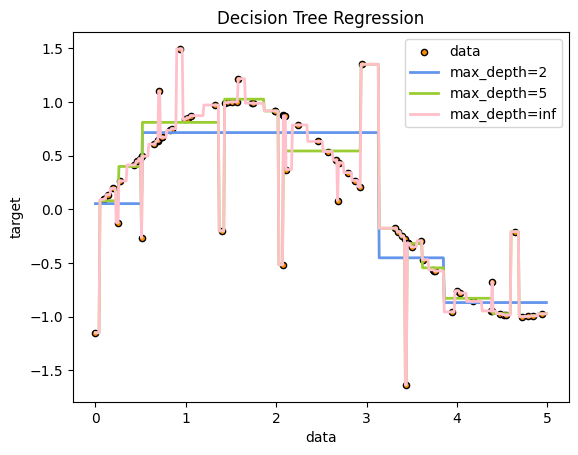

In [36]:
rng = np.random.RandomState(1)
X = np.sort(5 * rng.rand(80, 1), axis=0)
y = np.sin(X).ravel()
y[::5] += 3 * (0.5 - rng.rand(16))

df_1 = pd.DataFrame({
    "X": X.ravel(),
    "y": y 
})
regr_1 = RegressionTreeNico()
regr_2 = RegressionTreeNico()
regr_3= RegressionTreeNico()
regr_1.fit(df_1, "y", max_depth=2)
regr_2.fit(df_1, "y", max_depth=5)
regr_3.fit(df_1, "y")


X_test = np.arange(0.0, 5.0, 0.01)[:, np.newaxis]
X_test = pd.DataFrame({"X": X_test.ravel()})
y_1 = regr_1.predict(X_test)
y_2 = regr_2.predict(X_test)
y_3 = regr_3.predict(X_test)

plt.figure()
plt.scatter(X, y, s=20, edgecolor="black", c="darkorange", label="data")
plt.plot(X_test, y_1, color="cornflowerblue", label="max_depth=2", linewidth=2)
plt.plot(X_test, y_2, color="yellowgreen", label="max_depth=5", linewidth=2)
plt.plot(X_test, y_3, color="pink", label="max_depth=inf", linewidth=2)

plt.xlabel("data")
plt.ylabel("target")
plt.title("Decision Tree Regression")
plt.legend()
plt.show()

In [37]:
regr_1.cost_complexity_pruning_path(regr_1.tree_)
regr_1.tree_

{'feature': 'X',
 'threshold': np.float64(3.132750455307683),
 'left': {'feature': 'X',
  'threshold': np.float64(0.5139010885136697),
  'left': {'samples': 11,
   'prediction': 0.052360677956274054,
   'error': np.float64(0.1918613493495818)},
  'right': {'samples': 40,
   'prediction': 0.7138256817142807,
   'error': np.float64(0.14786394184525326)},
  'samples': 51,
  'prediction': 0.5711567593351029,
  'error': np.float64(0.23136965662280937)},
 'right': {'feature': 'X',
  'threshold': np.float64(3.8502285789691104),
  'left': {'samples': 14,
   'prediction': -0.45190263977283723,
   'error': np.float64(0.12412831704031613)},
  'right': {'samples': 15,
   'prediction': -0.8686425569863078,
   'error': np.float64(0.04072480715769879)},
  'samples': 29,
  'prediction': -0.6674577693660114,
  'error': np.float64(0.12435498351697538)},
 'samples': 80,
 'prediction': 0.12215899268094885,
 'error': np.float64(0.5471130002937142)}

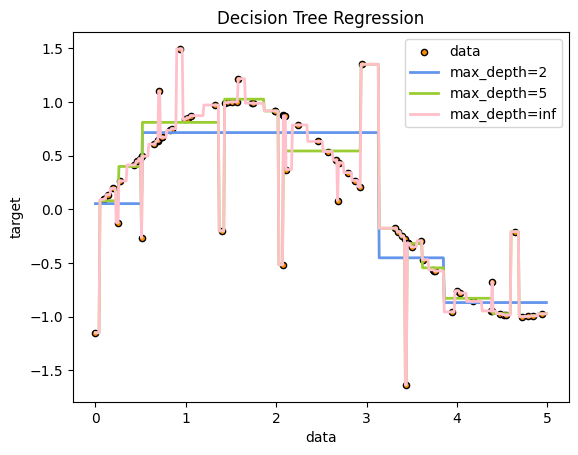

In [38]:
regr_1 = DecisionTreeRegressor(max_depth=2)
regr_2 = DecisionTreeRegressor(max_depth=5)
regr_3 = DecisionTreeRegressor()

regr_1.fit(X, y)
regr_2.fit(X, y)
regr_3.fit(X, y)


X_test = np.arange(0.0, 5.0, 0.01)[:, np.newaxis]
y_1 = regr_1.predict(X_test)
y_2 = regr_2.predict(X_test)
y_3 = regr_3.predict(X_test)


import matplotlib.pyplot as plt

plt.figure()
plt.scatter(X, y, s=20, edgecolor="black", c="darkorange", label="data")
plt.plot(X_test, y_1, color="cornflowerblue", label="max_depth=2", linewidth=2)
plt.plot(X_test, y_2, color="yellowgreen", label="max_depth=5", linewidth=2)
plt.plot(X_test, y_3, color="pink", label="max_depth=inf", linewidth=2)

plt.xlabel("data")
plt.ylabel("target")
plt.title("Decision Tree Regression")
plt.legend()
plt.show()

In [39]:
testTree = RegressionTreeNico()
treee = testTree.fit(df, categorical_features=["season", "holiday", "weekday", "weathersit"], target_name="cnt")

data_encoded = pd.get_dummies(df[["season", "holiday", "weekday", "weathersit"]], drop_first=True)
sk_tree = DecisionTreeRegressor(random_state=42)
sk_tree.fit(data_encoded, df["cnt"])
y_pred = sk_tree.predict(df.drop("cnt", axis=1))

y_pred

array([2365.        , 2485.16666667, 2968.92857143, 3339.625     ,
       3355.76923077, 2992.375     , 2837.53333333, 2365.        ,
       2156.38095238, 2968.92857143, 1920.75      , 3355.76923077,
       2992.375     , 2881.90909091, 2365.        , 2156.38095238,
       1053.5       , 1920.75      , 2070.5       , 2981.75      ,
       2881.90909091, 2490.875     , 2156.38095238, 2968.92857143,
       1920.75      ,  473.5       , 2992.375     , 2837.53333333,
       2490.875     , 2156.38095238, 1900.66666667, 1920.75      ,
       2070.5       , 2992.375     , 2837.53333333, 2365.        ,
       2156.38095238, 2968.92857143, 3339.625     , 2070.5       ,
       2992.375     , 2881.90909091, 2490.875     , 2156.38095238,
       2968.92857143, 3339.625     , 3355.76923077, 2992.375     ,
       2881.90909091, 2490.875     , 2156.38095238, 1053.5       ,
       3339.625     , 3355.76923077, 2981.75      , 2837.53333333,
       2490.875     , 2156.38095238, 1900.66666667, 3339.625  

In [40]:
y_pred_custom = treee.predict(df.drop("cnt", axis=1))
y_pred_custom

0      2419.888889
1      2419.888889
2      2968.928571
3      3339.625000
4      3355.769231
          ...     
726    2419.888889
727    2419.888889
728    2419.888889
729    2156.380952
730    2419.888889
Length: 731, dtype: float64

In [41]:
df_continous

,X,y
0,-10.000000,100.640523
1,-9.797980,83.406021
2,-9.595960,85.677901
3,-9.393939,94.867151
4,-9.191919,87.783120
...,...,...
95,9.191919,112.940948
96,9.393939,110.138976
97,9.595960,132.133065
98,9.797980,119.865489


In [42]:
testTree = RegressionTreeNico()
treee = testTree.fit(df_continous,target_name="y")
y_pred_custom = treee.predict(pd.DataFrame(df_continous.drop("y", axis=1)))

sk_tree = DecisionTreeRegressor(random_state=42)
sk_tree.fit(df_continous.drop("y", axis=1), df_continous["y"])
y_pred = sk_tree.predict(df_continous.drop("y", axis=1))

check = pd.DataFrame(pd.Series(y_pred) == y_pred_custom)
check[check[0] == False]

,0


In [43]:
# compare what happens if decoded! 
testTree = RegressionTreeNico()
sk_tree = DecisionTreeRegressor(random_state=42)

data_encoded = pd.get_dummies(df[["season", "holiday", "weekday", "weathersit"]], drop_first=True)
data_encoded2 = pd.get_dummies(
    df, 
    columns=["season", "holiday", "weekday", "weathersit"], 
    drop_first=True
)

treee = testTree.fit(df, categorical_features=["season", "holiday", "weekday", "weathersit"], target_name= "cnt")
y_pred_custom = treee.predict(pd.DataFrame(df.drop("cnt", axis=1)))

sk_tree.fit(data_encoded, df["cnt"])
y_pred = sk_tree.predict(data_encoded)

check = pd.DataFrame(pd.Series(y_pred) == y_pred_custom)
check[check[0] == False]
pd.Series(y_pred).unique()

array([2365.        , 2485.16666667, 2968.92857143, 3339.625     ,
       3355.76923077, 2992.375     , 2837.53333333, 2156.38095238,
       1920.75      , 2881.90909091, 1053.5       , 2070.5       ,
       2981.75      , 2490.875     ,  473.5       , 1900.66666667,
        623.        , 4344.5       , 5051.5       , 3965.16666667,
       4232.42857143, 5846.22222222, 6178.35294118, 4372.9       ,
       4550.83333333, 1685.        , 3919.14285714, 4107.75      ,
       5659.6       , 4560.66666667, 5531.        , 5771.94444444,
       3126.        ,  795.        , 5503.66666667, 5222.4       ,
       6054.31818182, 4478.42857143, 5890.05882353, 5931.05882353,
       5346.9       , 6038.        , 5899.66666667, 6318.5       ,
       5248.83333333, 4697.        , 5513.6       , 5567.70588235,
       5153.33333333, 5056.33333333, 2710.        , 1996.        ,
       1842.        , 4744.44444444, 4907.71428571, 3885.        ,
       4989.75      , 4247.16666667, 4699.875     , 4903.36363

### "Testing" script for the tree

In [44]:
# Generate fake dataset 
X, y = make_regression(n_samples=1000, n_features=10, noise=0.5, random_state=42)
df = pd.DataFrame(X, columns=[f"feature_{i}" for i in range(X.shape[1])])
df["target"] = y

X = df.drop("target", axis=1)
Y = df["target"]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

# Test alpha values to test
alpha_values = [0.0, 0.001, 0.01, 0.1, 0.2, 0.5, 0.75, 1.0, 5, 10, 30, 40,  100, 1000,10000]
#alpha_values = [ 0.5, 0.75]#, 30, 40]

results = []

# Sklearn DecisionTree with different alphas
for alpha in alpha_values:
    start_fit = time.time()
    sk_tree = DecisionTreeRegressor(random_state=0, ccp_alpha=alpha)
    sk_tree.fit(X_train, Y_train)
    fit_time = time.time() - start_fit

    start_pred = time.time()
    preds = sk_tree.predict(X_test)
    pred_time = time.time() - start_pred

    results.append({
        "Model": "Sklearn DecisionTree",
        "Alpha": alpha,
        "Fit Time (s)": fit_time,
        "Pred Time (s)": pred_time,
        "MSE": mean_squared_error(Y_test, preds),
        "MAE": mean_absolute_error(Y_test, preds),
        "R2": r2_score(Y_test, preds)
    })

# RegressionTreeNico with different alphas
for alpha in alpha_values:
    start_fit = time.time()
    custom_tree = RegressionTreeNico(random_state=0)
    custom_tree.fit(X_train.join(Y_train), target_name="target", alpha=alpha)
    fit_time = time.time() - start_fit

    start_pred = time.time()
    preds = custom_tree.predict(X_test)
    pred_time = time.time() - start_pred

    results.append({
        "Model": "Custom RegressionTreeNico",
        "Alpha": alpha,
        "Fit Time (s)": fit_time,
        "Pred Time (s)": pred_time,
        "MSE": mean_squared_error(Y_test, preds),
        "MAE": mean_absolute_error(Y_test, preds),
        "R2": r2_score(Y_test, preds)
    })

summary_df = pd.DataFrame(results)
print("\n======= Comparison of Sklearn vs Custom Tree =======")
summary_df



======= Comparison of Sklearn vs Custom Tree =======


,Model,Alpha,Fit Time (s),Pred Time (s),MSE,MAE,R2
0,Sklearn DecisionTree,0.000,0.013873,0.008620,6762.991770,63.286725,0.634897
1,Sklearn DecisionTree,0.001,0.013653,0.000636,6763.351796,63.286431,0.634878
2,Sklearn DecisionTree,0.010,0.006538,0.000531,6753.907229,63.195708,0.635388
3,Sklearn DecisionTree,0.100,0.006093,0.000472,6765.035743,63.304969,0.634787
4,Sklearn DecisionTree,0.200,0.005675,0.000340,6765.053093,63.316541,0.634786
5,Sklearn DecisionTree,0.500,0.005493,0.000278,6832.384748,63.942224,0.631151
6,Sklearn DecisionTree,0.750,0.005450,0.000264,6832.425946,64.093760,0.631149
7,Sklearn DecisionTree,1.000,0.005665,0.000406,6872.839474,64.293865,0.628967
8,Sklearn DecisionTree,5.000,0.005556,0.000346,6536.394249,62.795038,0.647130
9,Sklearn DecisionTree,10.000,0.005543,0.000284,6340.110941,61.864500,0.657727


In [45]:
custom_tree = RegressionTreeNico(random_state=0)
custom_tree.fit(X_train.join(Y_train), target_name="target", alpha=100)
preds = custom_tree.predict(X_train)

print(mean_squared_error(Y_train, preds))
#pprint.pprint(custom_tree.tree_)

3855.101100773404


# Random Forest Implementation

## Description
The Random Forest approach is based on two concepts, called **bagging** and **subspace** sampling. 

+ Bagging is the short form for *bootstrap aggregation*. Here we create a multitude of datasets of the same length as the original dataset drawn from the original dataset with replacement (the *bootstrap* in bagging). We then train a tree model for each of the bootstrapped datasets and take the majority prediction of these models for a unseen query instance as our prediction (the *aggregation* in bagging). Here we take the mean or the median for regression tree models and the mode for classification tree models.



***Sources***
https://python-course.eu/machine-learning/random-forests-in-python.php


In [ ]:
class RandomForestNico():
    def __init__(self, random_state=None) -> None:
        self.random_state = random_state

    def fit(self, 
            data: pd.DataFrame, 
            target_name : str,
            min_instances: int = 2,
            max_depth: int = None,
            categorical_features: list = [], 
            nr_of_trees: int = 10) -> Self:
        '''
            Fit method for training the randomforest model, based on the custom Regressiontree implementation
        
        Parameters
        -------
        data : pd.DataFrame
            Training dataset containing features AND the target
        target_name: str
            Name of the target column
        min_instances : int, optional
            Minimum number of samples required to allow further splitting, else mean is taken.
        max_depth : int, optional
            Maximum depth of the tree. If None, the tree grows until min_instances is reached
        categorical_features : list, optional (but actually necessary in case of such)
            List of feature names that represent categorical features
        nr_of_trees: int
            Define how many trees shall be fit for the RandomForest

        Returns
        -------
        Self
            Stores the learned forest in `self.forest_` of the initialized instance of this class.
        '''

        # Using the parallelized way taken from https://www.geeksforgeeks.org/python/massively-speed-up-processing-using-joblib-in-python/
        random_forest_trees = Parallel(n_jobs=-1)(
            delayed(RegressionTreeNico(random_state=self.random_state + i).fit) 
            (   
                # Bootstrap Sampling:
                # replace=True ensures sampling WITH replacement (i.e. we have some rows duplicated or similar). frac=1 ensures same data lengths as originally
                data = data.sample(frac=1, replace=True, random_state=self.random_state + i), 
                target_name = target_name, 
                min_instances = min_instances,
                max_depth = max_depth,
                max_features = int(len(data.columns) / 3),
                categorical_features=categorical_features
            )
            for i in range(nr_of_trees)
        )

        # list of the trees about to be trained
        '''random_forest_trees = []
        
        for i in range(nr_of_trees):
            # initialize tree class new each time
            tree = RegressionTreeNico(random_state=self.random_state + i)

            # Bootstrap Sampling:
            # replace=True ensures sampling WITH replacement (i.e. we have some rows duplicated or similar). frac=1 ensures same data lengths as originally
            bootstrap_sample = data.sample(frac=1, replace=True, random_state=self.random_state + i)
            #, random_state=self.random_state) >> Dont simply set it like that, because then you'll have the same bootstrapped sample each run

            random_forest_trees.append(
                tree.fit(data = bootstrap_sample, 
                         target_name = target_name, 
                         min_instances = min_instances,
                         max_depth = max_depth,
                         max_features = int(len(bootstrap_sample.columns) / 3),
                         categorical_features=categorical_features)
            )
        '''
        # set as part of the class
        self._random_forest_trees = random_forest_trees

        return self
    
    def predict(self, X_pred: pd.DataFrame) -> pd.Series:
        '''
        
        Parameters
        -------
        X_pred : pd.DataFrame
            Input samples with the same columns used during training
        categorical_features : list, optional (but actually necessary in case of such)
            List of feature names that represent categorical features        

        Returns
        -------
            Averaged predictions based on the predictions of all the trees
        '''

        # Make sure its trained
        if not hasattr(self, "_random_forest_trees"):
            raise ValueError("The random forest has not been trained yet. Use .fit() method of this class instance for that.")
        
        # "Old" non-parallelized way instead of https://www.geeksforgeeks.org/python/massively-speed-up-processing-using-joblib-in-python/
        # Collect all the predictions from the trained trees
        #all_preds = []

        #for tree in self._random_forest_trees:
        #    y_pred = tree.predict(X_pred, categorical_features=categorical_features)
        #    all_preds.append(y_pred.values)

        # n_jobs=-1 for using all cores available
        all_preds = Parallel(n_jobs=-1)(
            delayed(tree.predict) (X_pred) 
            for tree in self._random_forest_trees)

        # convert from series to array
        all_preds = [pred.values for pred in all_preds]

        # Average across all predictions
        mean_preds = np.mean(all_preds, axis=0)
        return pd.Series(mean_preds, index=X_pred.index)

## Testing Area

In [28]:
df = pd.read_csv("day.csv",usecols=['season','holiday','weekday','weathersit','cnt'])
df_example = df.sample(frac=0.012)

df

,season,holiday,weekday,weathersit,cnt
0,1,0,6,2,985
1,1,0,0,2,801
2,1,0,1,1,1349
3,1,0,2,1,1562
4,1,0,3,1,1600
...,...,...,...,...,...
726,1,0,4,2,2114
727,1,0,5,2,3095
728,1,0,6,2,1341
729,1,0,0,1,1796


In [29]:
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score



X = df.drop("cnt", axis=1)
Y = df["cnt"]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)


# sklearn forest
regressor = RandomForestRegressor(n_estimators=100, random_state=0)
regressor.fit(X_train, Y_train)
sk_preds = regressor.predict(X_test)

print("Sklearn Test Scores")
print("MSE:", mean_squared_error(Y_test, sk_preds))
print("R2:", r2_score(Y_test, sk_preds))

# custom forest
custom_model = RandomForestNico(random_state=0)
custom_forest = custom_model.fit(X_train.join(Y_train), target_name="cnt", nr_of_trees=100, categorical_features=["season", "holiday", "weekday", "weathersit"])
custom_preds = custom_forest.predict(X_test, categorical_features=["season", "holiday", "weekday", "weathersit"])

print("Custom Test Scores")
print("MSE:", mean_squared_error(Y_test, custom_preds))
print("R2:", r2_score(Y_test, custom_preds))

# TREES
custom_treemodel = RegressionTreeNico(random_state=0)
custom_tree = custom_treemodel.fit(X_train.join(Y_train), categorical_features=["season", "holiday", "weekday", "weathersit"], target_name="cnt")
custom_pred = custom_tree.predict(X_test, categorical_features=["season", "holiday", "weekday", "weathersit"])

sk_tree = DecisionTreeRegressor(random_state=0)
sk_tree.fit(X_train, Y_train)
predictions = sk_tree.predict(X_test)

predictions

print("======= sklearn Implementation scores (single tree) =======")
mse = mean_squared_error(Y_test, predictions)
print(f'Mean Squared Error: {mse}')

r2 = r2_score(Y_test, predictions)
print(f'R-squared: {r2}')

print("======= Custom Implementation scores (single tree) =======")
mse = mean_squared_error(Y_test, custom_pred)
print(f'Mean Squared Error: {mse}')

r2 = r2_score(Y_test, custom_pred)
print(f'R-squared: {r2}')

Sklearn Test Scores
MSE: 2391985.6731793303
R2: 0.4034773339881933
Custom Test Scores
MSE: 2332590.0128070577
R2: 0.41828965417559083
======= sklearn Implementation scores (single tree) =======
Mean Squared Error: 2458478.2562708943
R-squared: 0.3868951556831406
======= Custom Implementation scores (single tree) =======
Mean Squared Error: 2368158.6617210736
R-squared: 0.40941940653383757


In [48]:
import time
import numpy as np
import pandas as pd

from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Import your custom implementations
# from your_module import RegressionTreeNico, RandomForestNico
df = pd.read_csv("day.csv",usecols=['season','holiday','weekday','weathersit','cnt'])
df_example = df.sample(frac=0.012)

# === 1. Generate synthetic dataset (replace with your own df later) ===
#X, y = make_regression(n_samples=5000, n_features=10, noise=0.5, random_state=42)

target = "cnt"
X = df.drop(target, axis=1)
y = df[target]

#df = pd.DataFrame(X, columns=[f"feature_{i}" for i in range(X.shape[1])])
#df[target] = y

X = df.drop(target, axis=1)
Y = df[target]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Storage for summary
results = []

# === 2. Sklearn RandomForest ===
start_time = time.time()
sk_forest = RandomForestRegressor(n_estimators=100, random_state=0, n_jobs=-1)
sk_forest.fit(X_train, Y_train)
sk_preds = sk_forest.predict(X_test)
sk_time = time.time() - start_time

print("======= Sklearn RandomForest =======")
print(f"Training + Prediction Time: {sk_time:.4f} seconds")
print(f"MSE: {mean_squared_error(Y_test, sk_preds):.4f}")
print(f"MAE: {mean_absolute_error(Y_test, sk_preds):.4f}")
print(f"R2: {r2_score(Y_test, sk_preds):.4f}")

cv_scores = cross_val_score(sk_forest, X, Y, cv=5, scoring="r2", n_jobs=-1)
print("Cross-Validation R2 Scores:", cv_scores)
print("Mean CV R2:", np.mean(cv_scores))

results.append(["Sklearn RandomForest", sk_time,
                mean_squared_error(Y_test, sk_preds),
                mean_absolute_error(Y_test, sk_preds),
                r2_score(Y_test, sk_preds),
                np.mean(cv_scores)])

# === 3. Custom RandomForestNico ===
start_time = time.time()
custom_forest = RandomForestNico(random_state=0)
custom_forest.fit(X_train.join(Y_train), categorical_features=['season','holiday','weekday','weathersit','cnt'], target_name=target, nr_of_trees=100)
custom_preds = custom_forest.predict(X_test)
custom_time = time.time() - start_time

print("======= Custom RandomForestNico =======")
print(f"Training + Prediction Time: {custom_time:.4f} seconds")
print(f"MSE: {mean_squared_error(Y_test, custom_preds):.4f}")
print(f"MAE: {mean_absolute_error(Y_test, custom_preds):.4f}")
print(f"R2: {r2_score(Y_test, custom_preds):.4f}")

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []
for train_idx, test_idx in kf.split(X):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    Y_tr, Y_te = Y.iloc[train_idx], Y.iloc[test_idx]
    model = RandomForestNico(random_state=0)
    model.fit(X_tr.join(Y_tr), target_name=target, categorical_features=['season','holiday','weekday','weathersit','cnt'],nr_of_trees=100)
    preds = model.predict(X_te)
    cv_scores.append(r2_score(Y_te, preds))
print("Cross-Validation R2 Scores:", cv_scores)
print("Mean CV R2:", np.mean(cv_scores))

results.append(["Custom RandomForestNico", custom_time,
                mean_squared_error(Y_test, custom_preds),
                mean_absolute_error(Y_test, custom_preds),
                r2_score(Y_test, custom_preds),
                np.mean(cv_scores)])

# === 4. Sklearn DecisionTree ===
start_time = time.time()
sk_tree = DecisionTreeRegressor(random_state=0)
sk_tree.fit(X_train, Y_train)
sk_tree_preds = sk_tree.predict(X_test)
sk_tree_time = time.time() - start_time

print("======= Sklearn DecisionTree =======")
print(f"Training + Prediction Time: {sk_tree_time:.4f} seconds")
print(f"MSE: {mean_squared_error(Y_test, sk_tree_preds):.4f}")
print(f"MAE: {mean_absolute_error(Y_test, sk_tree_preds):.4f}")
print(f"R2: {r2_score(Y_test, sk_tree_preds):.4f}")

cv_scores = cross_val_score(sk_tree, X, Y, cv=5, scoring="r2")
print("Cross-Validation R2 Scores:", cv_scores)
print("Mean CV R2:", np.mean(cv_scores))

results.append(["Sklearn DecisionTree", sk_tree_time,
                mean_squared_error(Y_test, sk_tree_preds),
                mean_absolute_error(Y_test, sk_tree_preds),
                r2_score(Y_test, sk_tree_preds),
                np.mean(cv_scores)])

# === 5. Custom RegressionTreeNico ===
start_time = time.time()
custom_tree = RegressionTreeNico(random_state=0)
custom_tree.fit(X_train.join(Y_train), target_name=target)
custom_tree_preds = custom_tree.predict(X_test)
custom_tree_time = time.time() - start_time

print("======= Custom RegressionTreeNico =======")
print(f"Training + Prediction Time: {custom_tree_time:.4f} seconds")
print(f"MSE: {mean_squared_error(Y_test, custom_tree_preds):.4f}")
print(f"MAE: {mean_absolute_error(Y_test, custom_tree_preds):.4f}")
print(f"R2: {r2_score(Y_test, custom_tree_preds):.4f}")

cv_scores = []
for train_idx, test_idx in kf.split(X):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    Y_tr, Y_te = Y.iloc[train_idx], Y.iloc[test_idx]
    model = RegressionTreeNico(random_state=0)
    model.fit(X_tr.join(Y_tr), target_name=target)
    preds = model.predict(X_te)
    cv_scores.append(r2_score(Y_te, preds))
print("Cross-Validation R2 Scores:", cv_scores)
print("Mean CV R2:", np.mean(cv_scores))

results.append(["Custom RegressionTreeNico", custom_tree_time,
                mean_squared_error(Y_test, custom_tree_preds),
                mean_absolute_error(Y_test, custom_tree_preds),
                r2_score(Y_test, custom_tree_preds),
                np.mean(cv_scores)])

# === 6. Summary Table ===
summary_df = pd.DataFrame(results, columns=["Model", "Time (s)", "MSE", "MAE", "R2", "Mean CV R2"])
print("\n======= Summary Comparison =======")
print(summary_df)


======= Sklearn RandomForest =======
Training + Prediction Time: 0.0848 seconds
MSE: 2391985.6732
MAE: 1304.2683
R2: 0.4035
Cross-Validation R2 Scores: [-1.9891032  -5.28416775 -2.67127073 -3.3960395  -0.46333397]
Mean CV R2: -2.760783029561949


TypeError: RegressionTreeNico.predict() got an unexpected keyword argument 'categorical_features'